In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


In [21]:
class TaxiOption:
    def __init__(self, name, initiation, termination):
        self.name = name
        self.initiation = initiation
        self.termination = termination
        self.q_table = None

In [22]:
class HierarchicalAgent:
    def __init__(self, env, options, alpha=0.2, gamma=0.995, epsilon=0.3, epsilon_decay=0.9995):
        self.env = env
        self.options = options
        self.n_primitives = env.action_space.n
        self.n_actions = self.n_primitives + len(options)
        self.q_omega = np.zeros((env.observation_space.n, self.n_actions))
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.reward_history = []

        for option in self.options:
            # option.q_table = np.zeros((env.observation_space.n, self.n_primitives))
            option.q_table = np.random.uniform(-0.01, 0.01,
                    (env.observation_space.n, self.n_primitives))


    def decode_state(self, state):
        return self.env.unwrapped.decode(state)

    def get_action_mask(self, state):
        valid_actions = np.zeros(self.n_actions, dtype=bool)

        # Get valid primitives from environment dynamics
        valid_primitives = [a in self.env.unwrapped.P[state]
                          for a in range(self.n_primitives)]
        valid_actions[:self.n_primitives] = valid_primitives

        # Options
        for i, option in enumerate(self.options):
            valid_actions[self.n_primitives + i] = option.initiation(state)

        return valid_actions

    def option_policy(self, state, option):
        valid_actions = [action in self.env.unwrapped.P[state]
                        for action in range(self.n_primitives)]
        return np.argmax(option.q_table[state] * valid_actions)

In [23]:
class SMDPLearner(HierarchicalAgent):
    def train(self, episodes=2000):
        for _ in tqdm(range(episodes)):
            state, _ = self.env.reset()
            done = False
            total_reward = 0

            while not done:
                action_mask = self.get_action_mask(state)

                if np.random.random() < self.epsilon:
                    action = np.random.choice(np.where(action_mask)[0])
                else:
                    action = np.argmax(self.q_omega[state] * action_mask)

                if action < self.n_primitives:
                    next_state, reward, terminated, truncated, _ = self.env.step(action)
                    done = terminated or truncated
                    total_reward += reward

                    next_mask = self.get_action_mask(next_state)
                    target = reward + self.gamma * np.max(self.q_omega[next_state][next_mask])
                    self.q_omega[state][action] += self.alpha * (target - self.q_omega[state][action])
                    state = next_state
                else:
                    option = self.options[action - self.n_primitives]
                    option_reward = 0
                    steps = 0
                    start_state = state

                    while not done and not option.termination(state):
                        action = self.option_policy(state, option)
                        next_state, reward, terminated, truncated, _ = self.env.step(action)
                        done = terminated or truncated

                        valid_actions = [a in self.env.unwrapped.P[state] for a in range(self.n_primitives)]
                        target = reward + self.gamma * np.max(option.q_table[next_state] * valid_actions)
                        option.q_table[state][action] += self.alpha * (target - option.q_table[state][action])

                        option_reward += (self.gamma ** steps) * reward
                        state = next_state
                        steps += 1

                    next_mask = self.get_action_mask(state)
                    target = option_reward + (self.gamma ** steps) * np.max(self.q_omega[state][next_mask])
                    self.q_omega[start_state][action] += self.alpha * (target - self.q_omega[start_state][action])
                    total_reward += option_reward

            self.reward_history.append(total_reward)
            self.epsilon = max(0.01, self.epsilon * self.epsilon_decay)

In [24]:
class IntraOptionLearner(HierarchicalAgent):
    def train(self, episodes=2000):
        for _ in tqdm(range(episodes)):
            state, _ = self.env.reset()
            done = False
            total_reward = 0
            current_option = None

            while not done:
                if current_option is None or current_option.termination(state):
                    action_mask = self.get_action_mask(state)
                    if np.random.random() < self.epsilon:
                        action = np.random.choice(np.where(action_mask)[0])
                    else:
                        action = np.argmax(self.q_omega[state] * action_mask)

                    if action >= self.n_primitives:
                        current_option = self.options[action - self.n_primitives]
                    else:
                        current_option = None

                # In IntraOptionLearner's train loop:
                if current_option:
                    action = self.option_policy(state, current_option)
                else:
                    # Restrict to primitive actions only
                    primitive_mask = self.get_action_mask(state)[:self.n_primitives]
                    if np.any(primitive_mask):
                        if np.random.random() < self.epsilon:
                            action = np.random.choice(np.where(primitive_mask)[0])
                        else:
                            action = np.argmax(self.q_omega[state][:self.n_primitives] * primitive_mask)
                    else:  # Fallback for edge cases
                        action = np.random.choice(self.n_primitives)

                next_state, reward, terminated, truncated, _ = self.env.step(action)
                done = terminated or truncated
                total_reward += reward

                for option in self.options:
                    if option.initiation(state) and self.option_policy(state, option) == action:
                        valid_actions = [a in self.env.unwrapped.P[next_state] for a in range(self.n_primitives)]
                        if option.termination(next_state):
                            target = reward + self.gamma * np.max(self.q_omega[next_state][self.get_action_mask(next_state)])
                        else:
                            target = reward + self.gamma * np.max(option.q_table[next_state] * valid_actions)
                        option.q_table[state][action] += self.alpha * (target - option.q_table[state][action])

                action_mask = self.get_action_mask(state)
                target = reward + self.gamma * np.max(self.q_omega[next_state][self.get_action_mask(next_state)])
                self.q_omega[state][action] += self.alpha * (target - self.q_omega[state][action])
                state = next_state

            self.reward_history.append(total_reward)
            self.epsilon = max(0.01, self.epsilon * self.epsilon_decay)

In [25]:
def decode_state(state):
    return env.unwrapped.decode(state)

def get_initiation(state, target_loc):
    taxi_row, taxi_col, pass_loc, dest_idx = decode_state(state)
    return (taxi_row, taxi_col) != target_loc and pass_loc != 4

def put_initiation(state, target_idx):
    taxi_row, taxi_col, pass_loc, dest_idx = decode_state(state)
    target_loc = passenger_locs[target_idx]
    return pass_loc == 4 and dest_idx == target_idx and (taxi_row, taxi_col) != target_loc

def get_termination(state, target_loc):
    taxi_row, taxi_col, pass_loc, _ = decode_state(state)
    return (taxi_row, taxi_col) == target_loc and pass_loc == 4

def put_termination(state, target_idx):
    decoded_state = decode_state(state)
    taxi_row, taxi_col, pass_loc, dest_idx = decoded_state
    target_loc = passenger_locs[dest_idx]  # Use destination from state
    return (taxi_row, taxi_col) == target_loc and pass_loc == 4

def plot_comparison(smdp_rewards, intra_rewards, window=100):
    plt.figure(figsize=(12,6))
    plt.plot(np.convolve(smdp_rewards, np.ones(window)/window, mode='valid'), label='SMDP Q-Learning')
    plt.plot(np.convolve(intra_rewards, np.ones(window)/window, mode='valid'), label='Intra-Option Q-Learning')
    plt.title('Performance Comparison')
    plt.xlabel('Episode')
    plt.ylabel('Average Reward')
    plt.legend()
    plt.grid(True)
    plt.show()

In [26]:
env = gym.make('Taxi-v3')
passenger_locs = env.unwrapped.locs

In [27]:

options = []
for i, loc in enumerate(passenger_locs):
    options.append(TaxiOption(
        f"GET_{i}",
        lambda s, loc=loc: get_initiation(s, loc),
        lambda s, loc=loc: get_termination(s, loc)
    ))
    options.append(TaxiOption(
        f"PUT_{i}",
        lambda s, i=i: put_initiation(s, i),
        lambda s, i=i: put_termination(s, i)
    ))

In [28]:
smdp_agent = SMDPLearner(env, options)
intra_agent = IntraOptionLearner(env, options)

smdp_agent.train(5000)
intra_agent.train(5000)

100%|██████████| 5000/5000 [00:21<00:00, 236.34it/s]


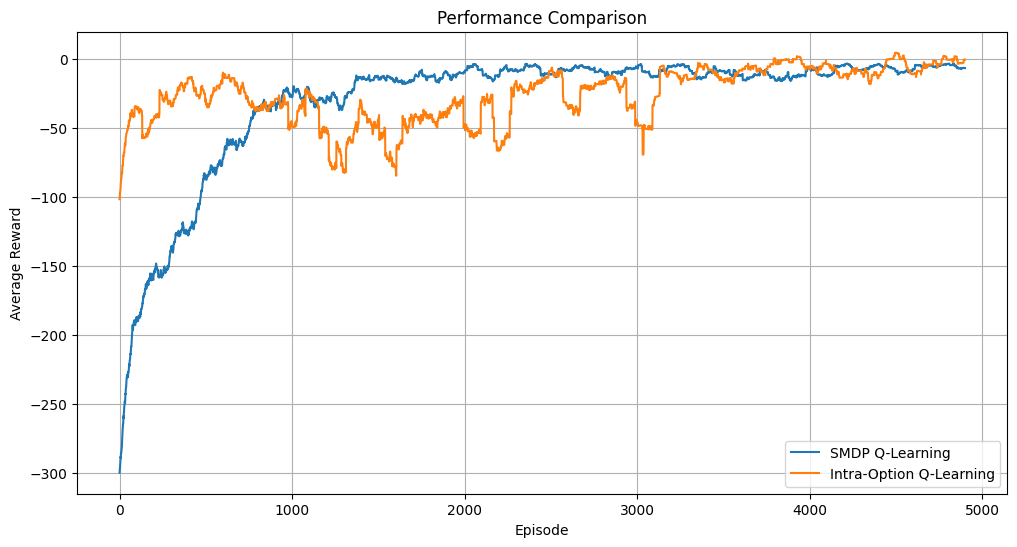

In [29]:

plot_comparison(smdp_agent.reward_history, intra_agent.reward_history)


In [30]:
options[0].q_table.shape, options[1].q_table.shape

((500, 6), (500, 6))

<ipython-input-31-fa652494f34d>:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis', 6)  # Updated for 6 actions


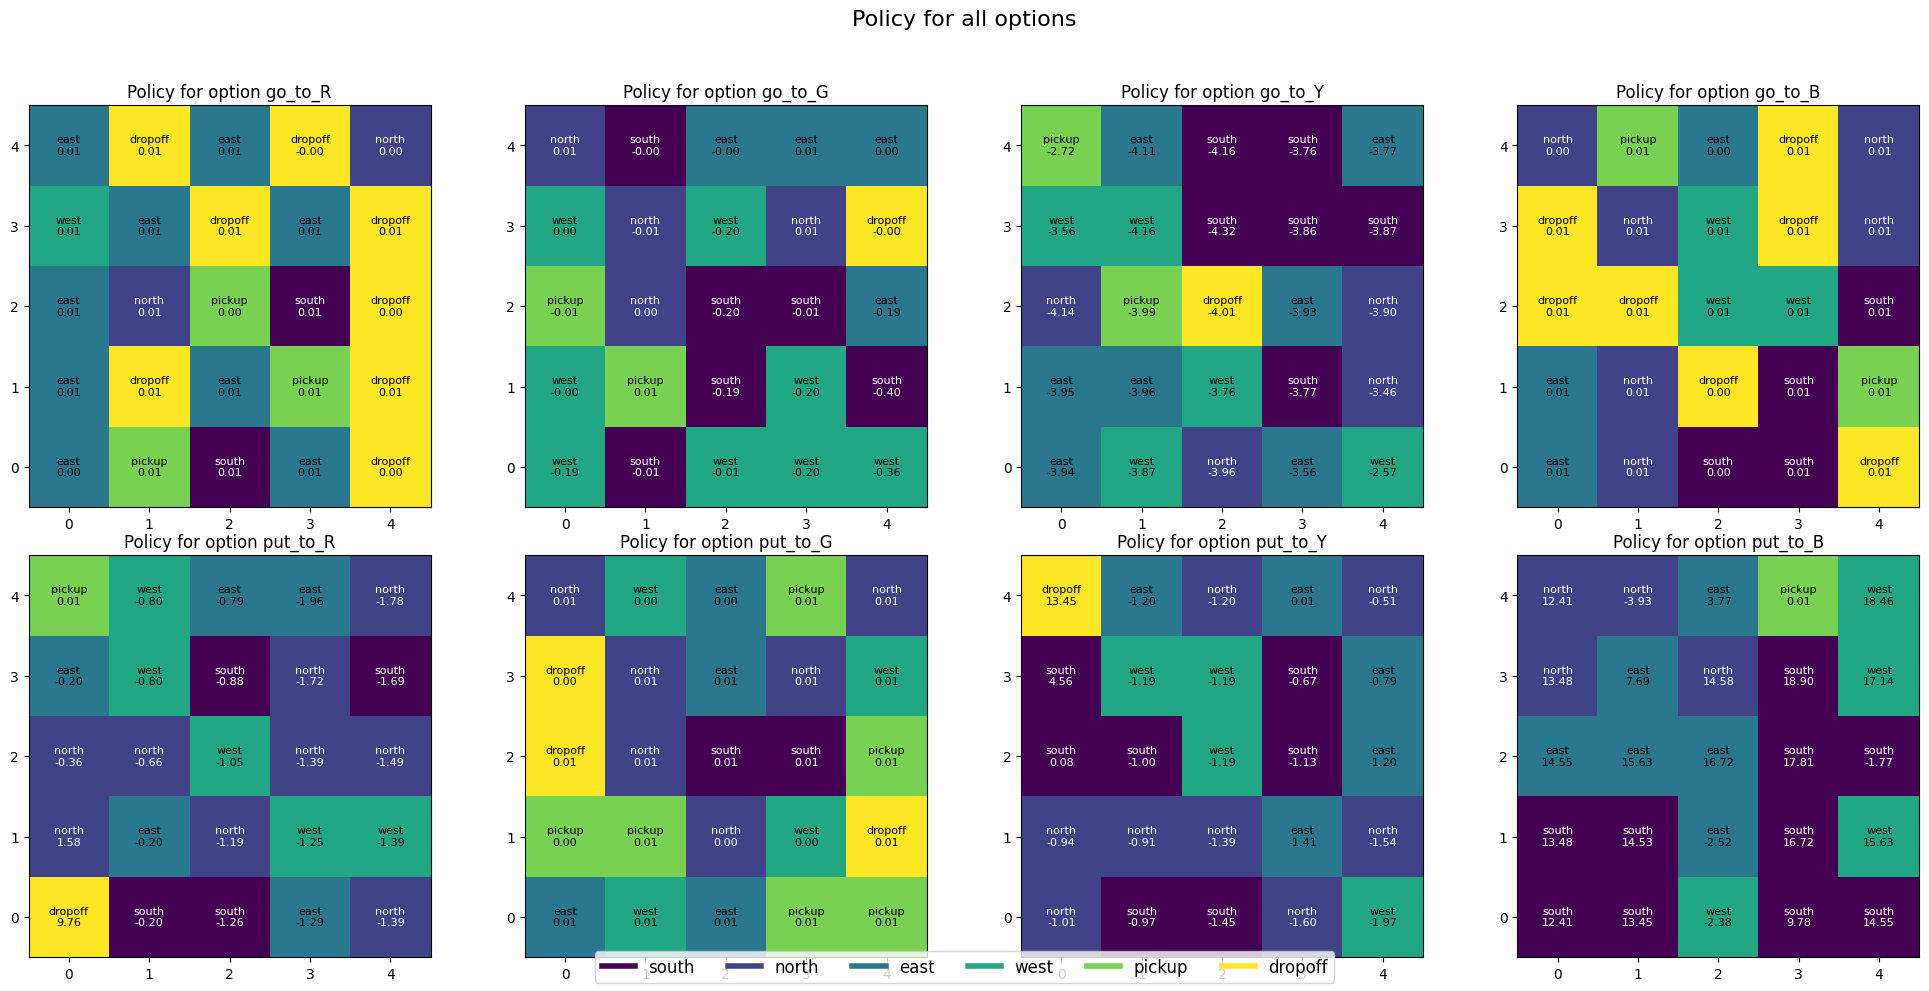

In [31]:
import matplotlib.pyplot as plt
import numpy as np

def plot_option_policies_dashboard(agent, env, options):
    action_names = ['south', 'north', 'east', 'west', 'pickup', 'dropoff']
    passenger_names = ['R', 'G', 'Y', 'B']

    # Create distinct color mapping for all 6 actions
    action_colors = {
        0: '#000033',  # south - dark blue
        1: '#800080',  # north - purple
        2: '#ff5733',  # east - orange-red
        3: '#f5f5dc',  # west - beige
        4: '#32cd32',  # pickup - green
        5: '#1e90ff'   # dropoff - light blue
    }
    cmap = plt.cm.get_cmap('viridis', 6)  # Updated for 6 actions

    # Setup figure for all options (4 GET + 4 PUT)
    fig, axs = plt.subplots(2, 4, figsize=(20, 10))

    # Plot all GET options
    for i in range(4):
        option = options[i]
        ax = axs[0, i]

        # Create grid to store best actions
        grid = np.zeros((5, 5))

        # For each taxi position
        for row in range(5):
            for col in range(5):
                # Encode state: taxi at (row,col), passenger at location i, arbitrary destination
                state = env.unwrapped.encode(row, col, i, 0)
                # Get best primitive action (0-5)
                best_action = np.argmax(option.q_table[state])
                grid[row, col] = best_action

        # Visualize with colors
        im = ax.imshow(grid, cmap=cmap, vmin=0, vmax=5)

        # Add text labels with Q-values
        for r in range(5):
            for c in range(5):
                state = env.unwrapped.encode(r, c, i, 0)
                action_idx = int(grid[r, c])
                q_value = option.q_table[state][action_idx]  # Get actual Q-value
                text_color = 'white' if action_idx < 2 else 'black'
                ax.text(c, r, f"{action_names[action_idx]}\n{q_value:.2f}", ha='center', va='center',
                       color=text_color, fontsize=8)

        ax.set_title(f"Policy for option go_to_{passenger_names[i]}")
        ax.set_xticks(range(5))
        ax.set_yticks(range(5))
        ax.invert_yaxis()

    # Plot all PUT options
    for i in range(4):
        option = options[i+4]  # PUT options start after GET options
        ax = axs[1, i]

        grid = np.zeros((5, 5))
        for row in range(5):
            for col in range(5):
                # Passenger in taxi (pass_loc=4), destination i
                state = env.unwrapped.encode(row, col, 4, i)
                best_action = np.argmax(option.q_table[state])
                grid[row, col] = best_action

        im = ax.imshow(grid, cmap=cmap, vmin=0, vmax=5)
        for r in range(5):
            for c in range(5):
                state = env.unwrapped.encode(r, c, 4, i)
                action_idx = int(grid[r, c])
                q_value = option.q_table[state][action_idx]  # Get actual Q-value
                text_color = 'white' if action_idx < 2 else 'black'
                ax.text(c, r, f"{action_names[action_idx]}\n{q_value:.2f}", ha='center', va='center',
                       color=text_color, fontsize=8)

        ax.set_title(f"Policy for option put_to_{passenger_names[i]}")
        ax.set_xticks(range(5))
        ax.set_yticks(range(5))
        ax.invert_yaxis()

    plt.suptitle("Policy for all options", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    # Create custom legend with all 6 actions
    custom_lines = [plt.Line2D([0], [0], color=cmap(i/5), lw=4) for i in range(6)]
    fig.legend(custom_lines, action_names,
              loc='lower center', ncol=6, fontsize=12)

    plt.show()

# Call with your trained agent
plot_option_policies_dashboard(smdp_agent, env, options)


<ipython-input-31-fa652494f34d>:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis', 6)  # Updated for 6 actions


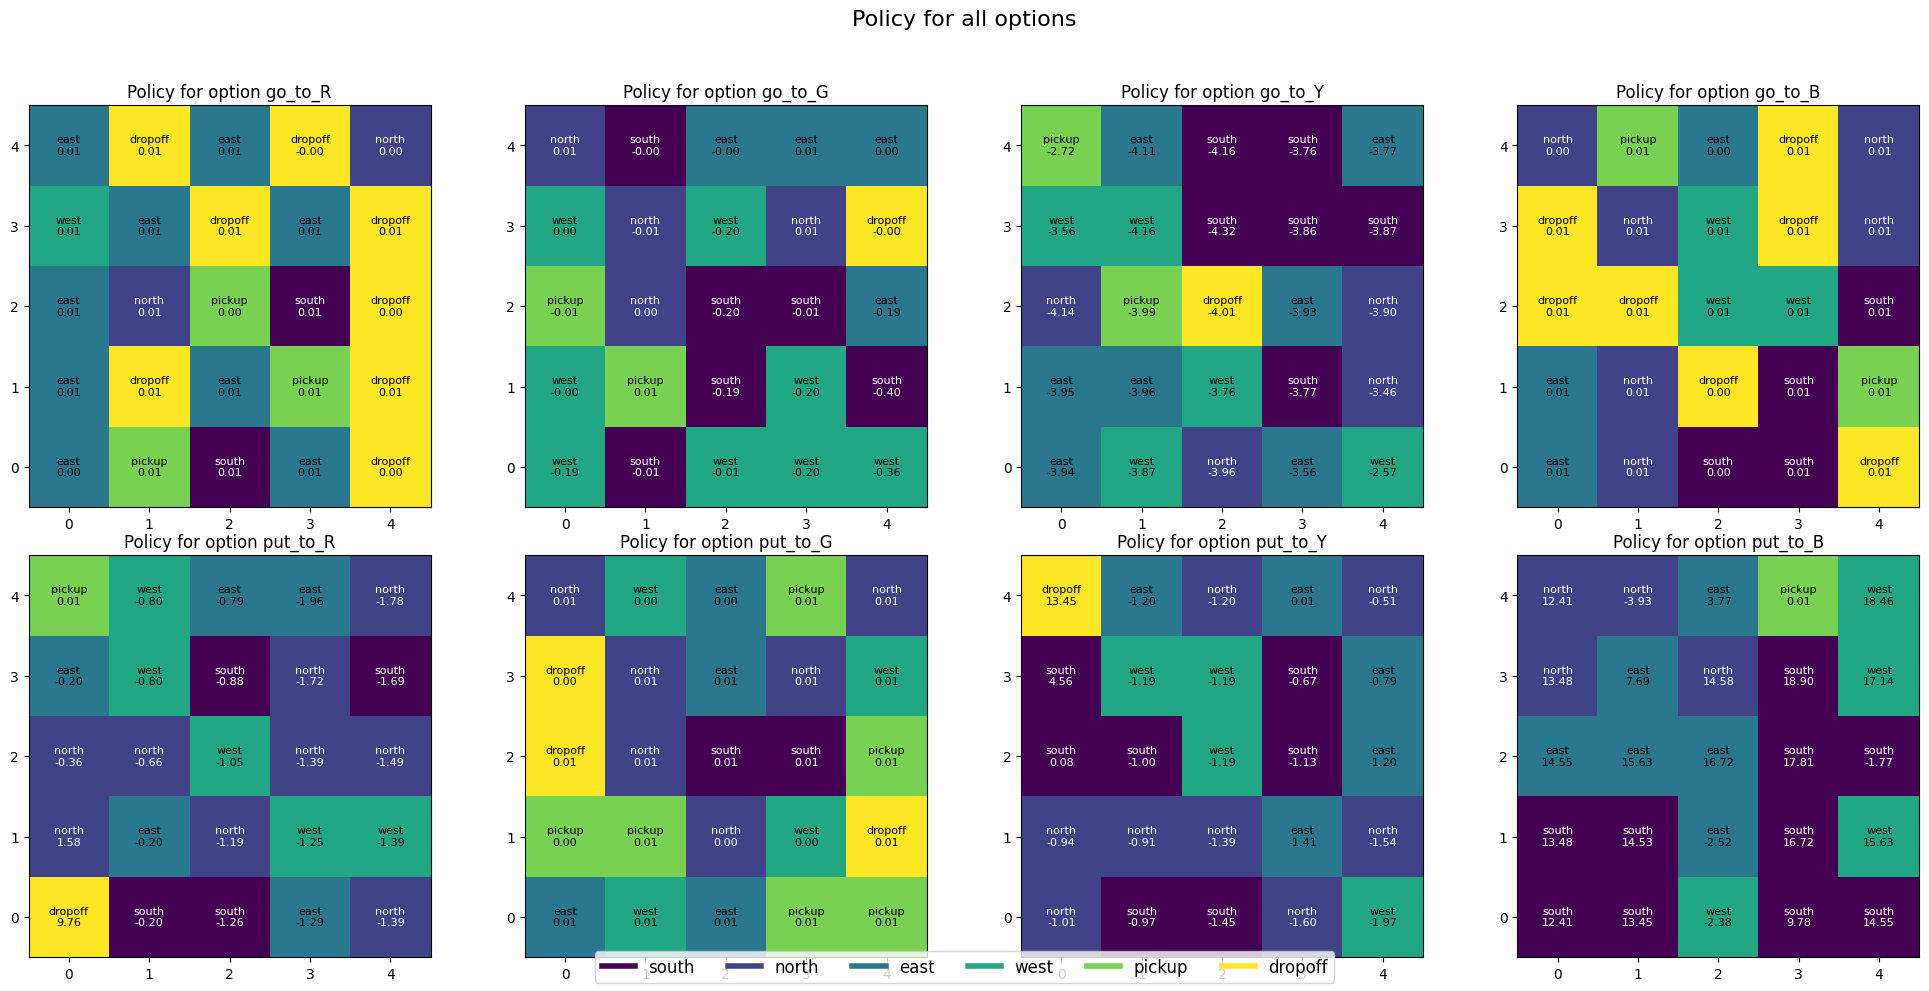

In [32]:
plot_option_policies_dashboard(intra_agent, env, options)


<ipython-input-33-5344affccc72>:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis', 14)


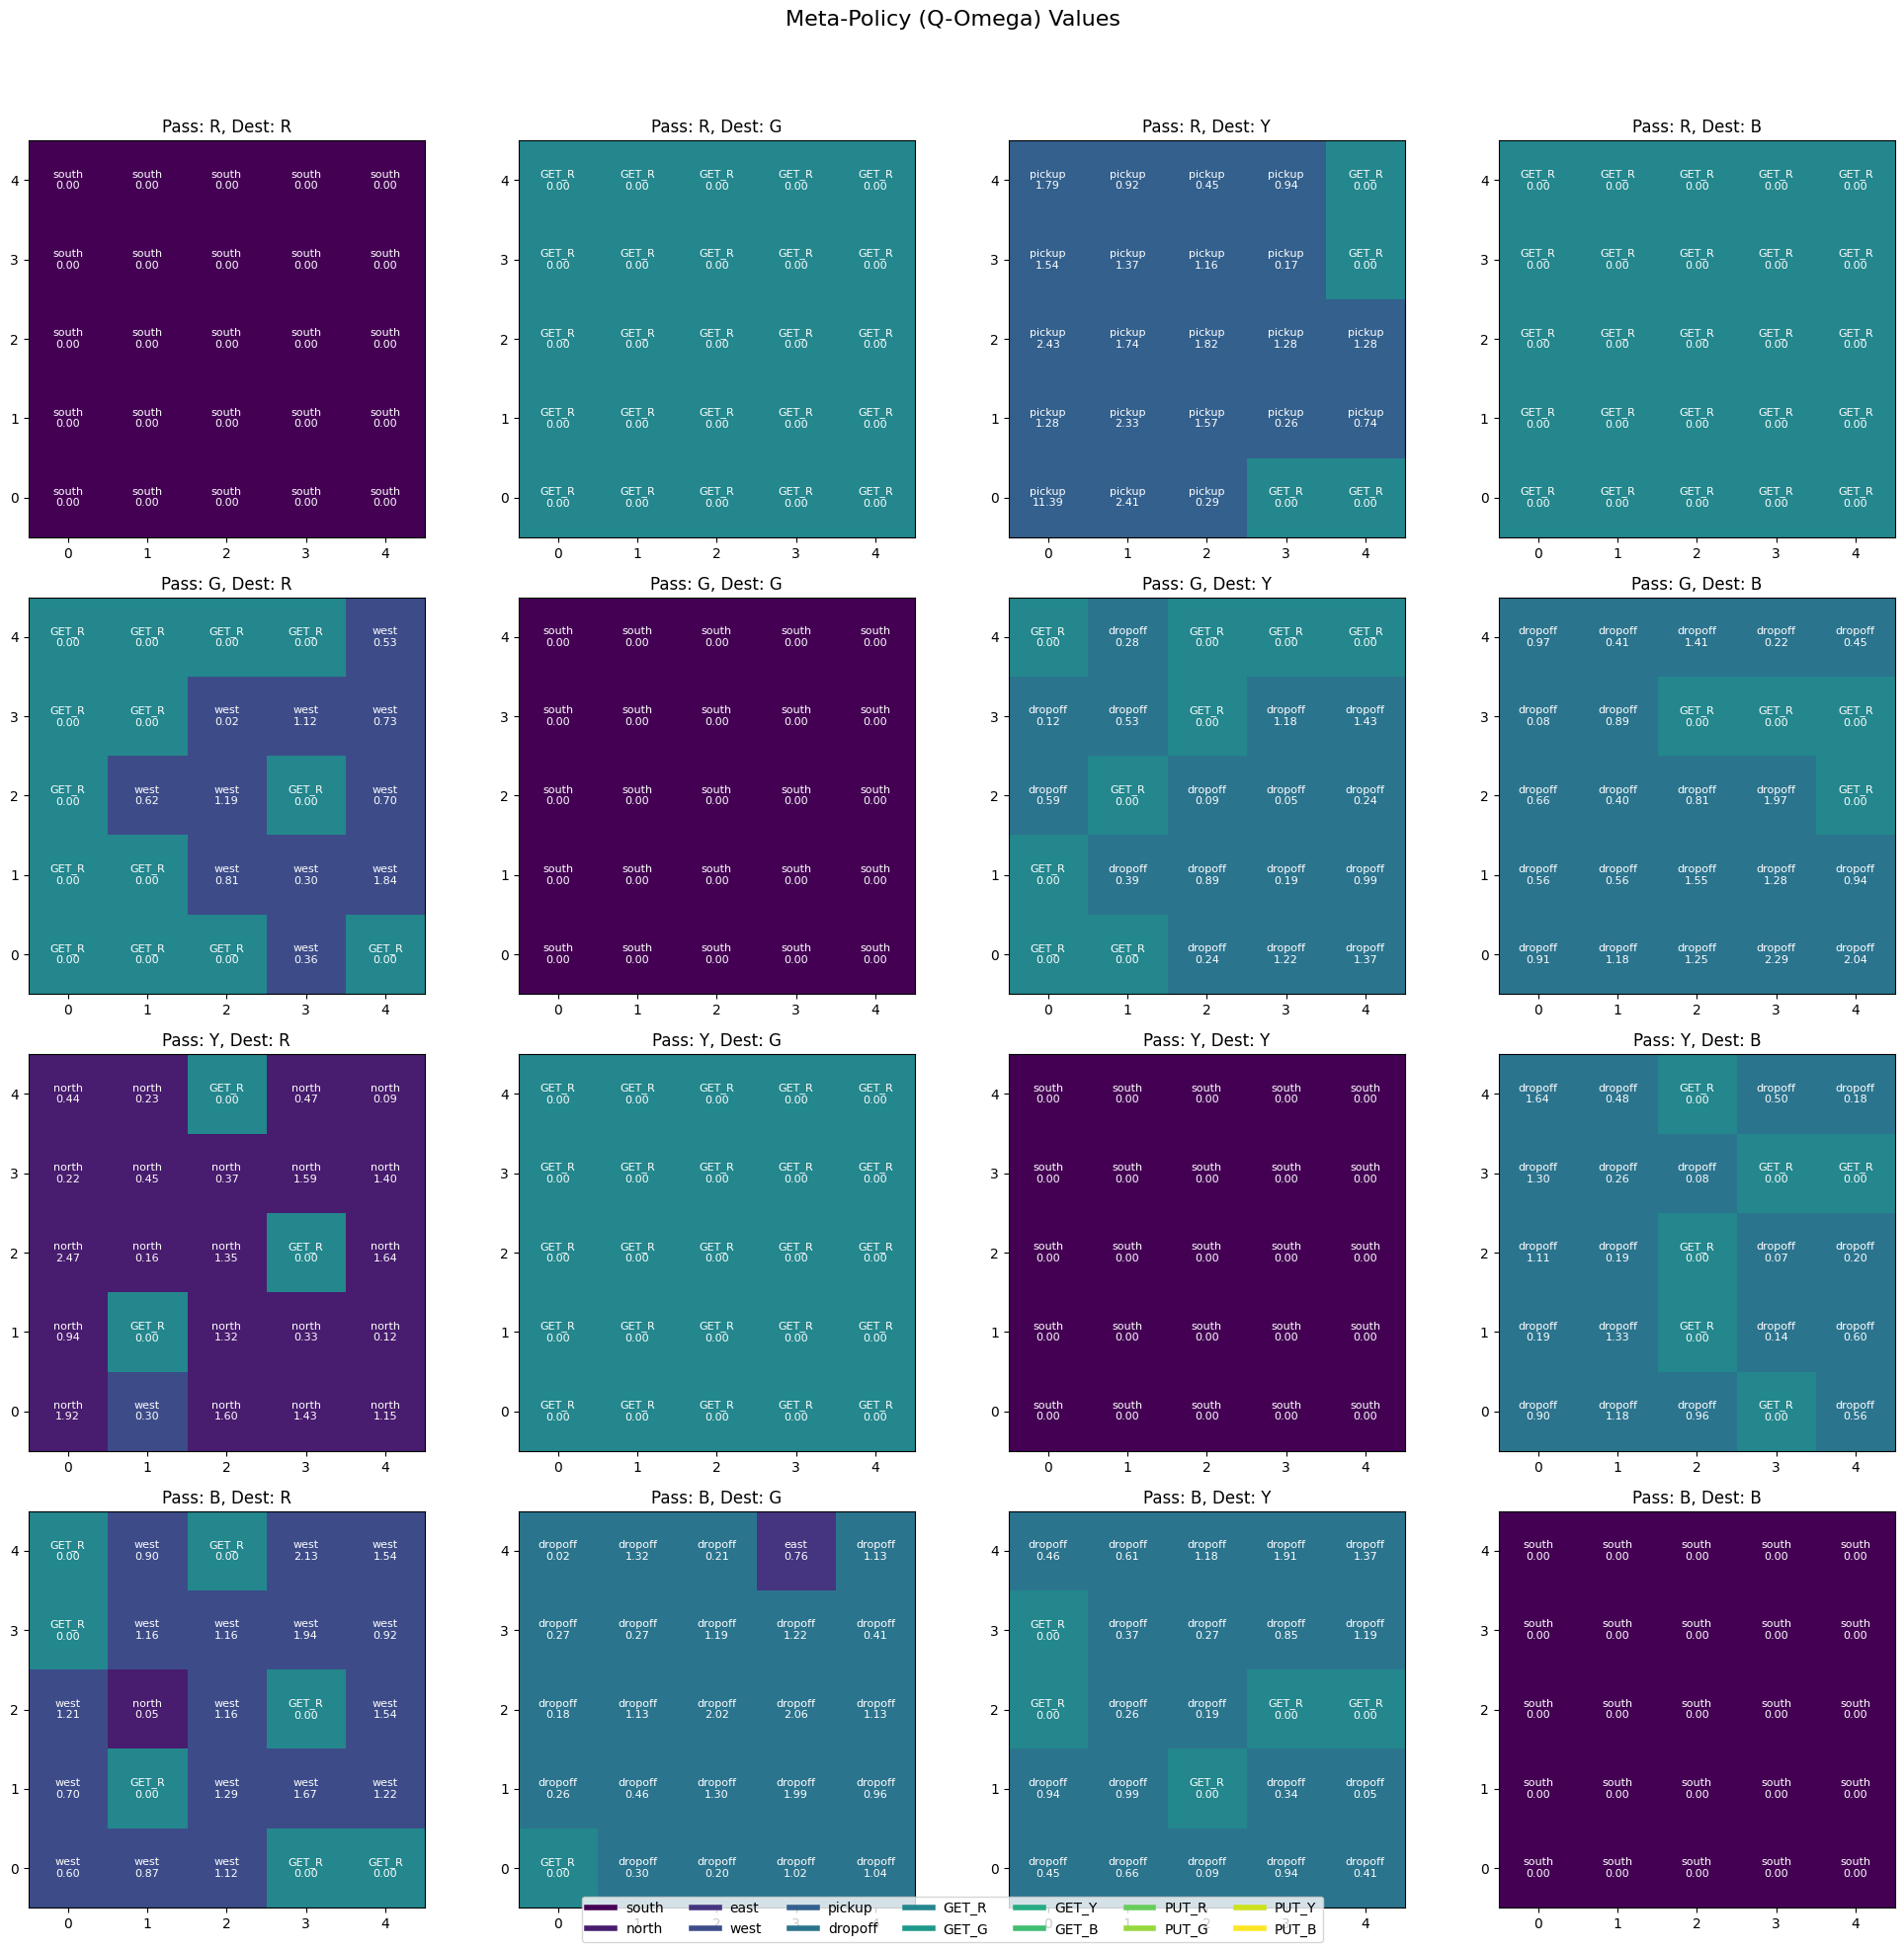

In [33]:
import matplotlib.pyplot as plt
import numpy as np

def plot_q_omega_dashboard(agent, env, options):
    # Options and primitive action names for display
    primitive_names = ['south', 'north', 'east', 'west', 'pickup', 'dropoff']
    option_names = ['GET_R', 'GET_G', 'GET_Y', 'GET_B', 'PUT_R', 'PUT_G', 'PUT_Y', 'PUT_B']
    passenger_locs = ['R', 'G', 'Y', 'B']

    # Creating distinct colors for all actions (6 primitives + 8 options)
    cmap = plt.cm.get_cmap('viridis', 14)
    # cmap = plt.cm.get_cmap('viridis', 6)
    # Create figures for different passenger and destination combinations
    fig, axs = plt.subplots(4, 4, figsize=(20, 20))

    # Loop through passenger locations and destinations
    for p_idx, p_loc in enumerate(range(4)):
        for d_idx, dest in enumerate(range(4)):
            ax = axs[p_idx, d_idx]

            # Create grid to store best actions/options
            grid = np.zeros((5, 5))
            label_grid = np.empty((5, 5), dtype=object)
            value_grid = np.zeros((5, 5))

            # For each taxi position in the grid
            for row in range(5):
                for col in range(5):
                    # Encode state: taxi at (row,col), passenger at p_loc, destination at dest
                    state = env.unwrapped.encode(row, col, p_loc, dest)

                    # Get best action from Q-omega (includes primitive and option indices)
                    best_idx = np.argmax(agent.q_omega[state])
                    value = agent.q_omega[state][best_idx]

                    grid[row, col] = best_idx
                    value_grid[row, col] = value

                    # Determine label (primitive action or option name)
                    if best_idx < agent.n_primitives:
                        label_grid[row, col] = primitive_names[best_idx]
                    else:
                        option_idx = best_idx - agent.n_primitives
                        label_grid[row, col] = option_names[option_idx]

            # Visualize with colors (normalize to 0-1 range for colormap)
            im = ax.imshow(grid, cmap=cmap, vmin=0, vmax=13)

            # Add text labels with action/option name and Q-value
            for r in range(5):
                for c in range(5):
                    text_color = 'white' if grid[r, c] < 7 else 'black'
                    text = f"{label_grid[r, c]}\n{value_grid[r, c]:.2f}"
                    ax.text(c, r, text, ha='center', va='center',
                           color=text_color, fontsize=8)

            ax.set_title(f"Pass: {passenger_locs[p_loc]}, Dest: {passenger_locs[dest]}")
            ax.set_xticks(range(5))
            ax.set_yticks(range(5))
            ax.invert_yaxis()

    plt.suptitle("Meta-Policy (Q-Omega) Values", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    # Create legend for all actions and options
    all_labels = primitive_names + option_names
    custom_lines = [plt.Line2D([0], [0], color=cmap(i/13), lw=4) for i in range(14)]
    fig.legend(custom_lines, all_labels,
              loc='lower center', ncol=7, fontsize=10)

    plt.show()

# Call with your trained agent
plot_q_omega_dashboard(smdp_agent, env, options)


<ipython-input-33-5344affccc72>:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis', 14)


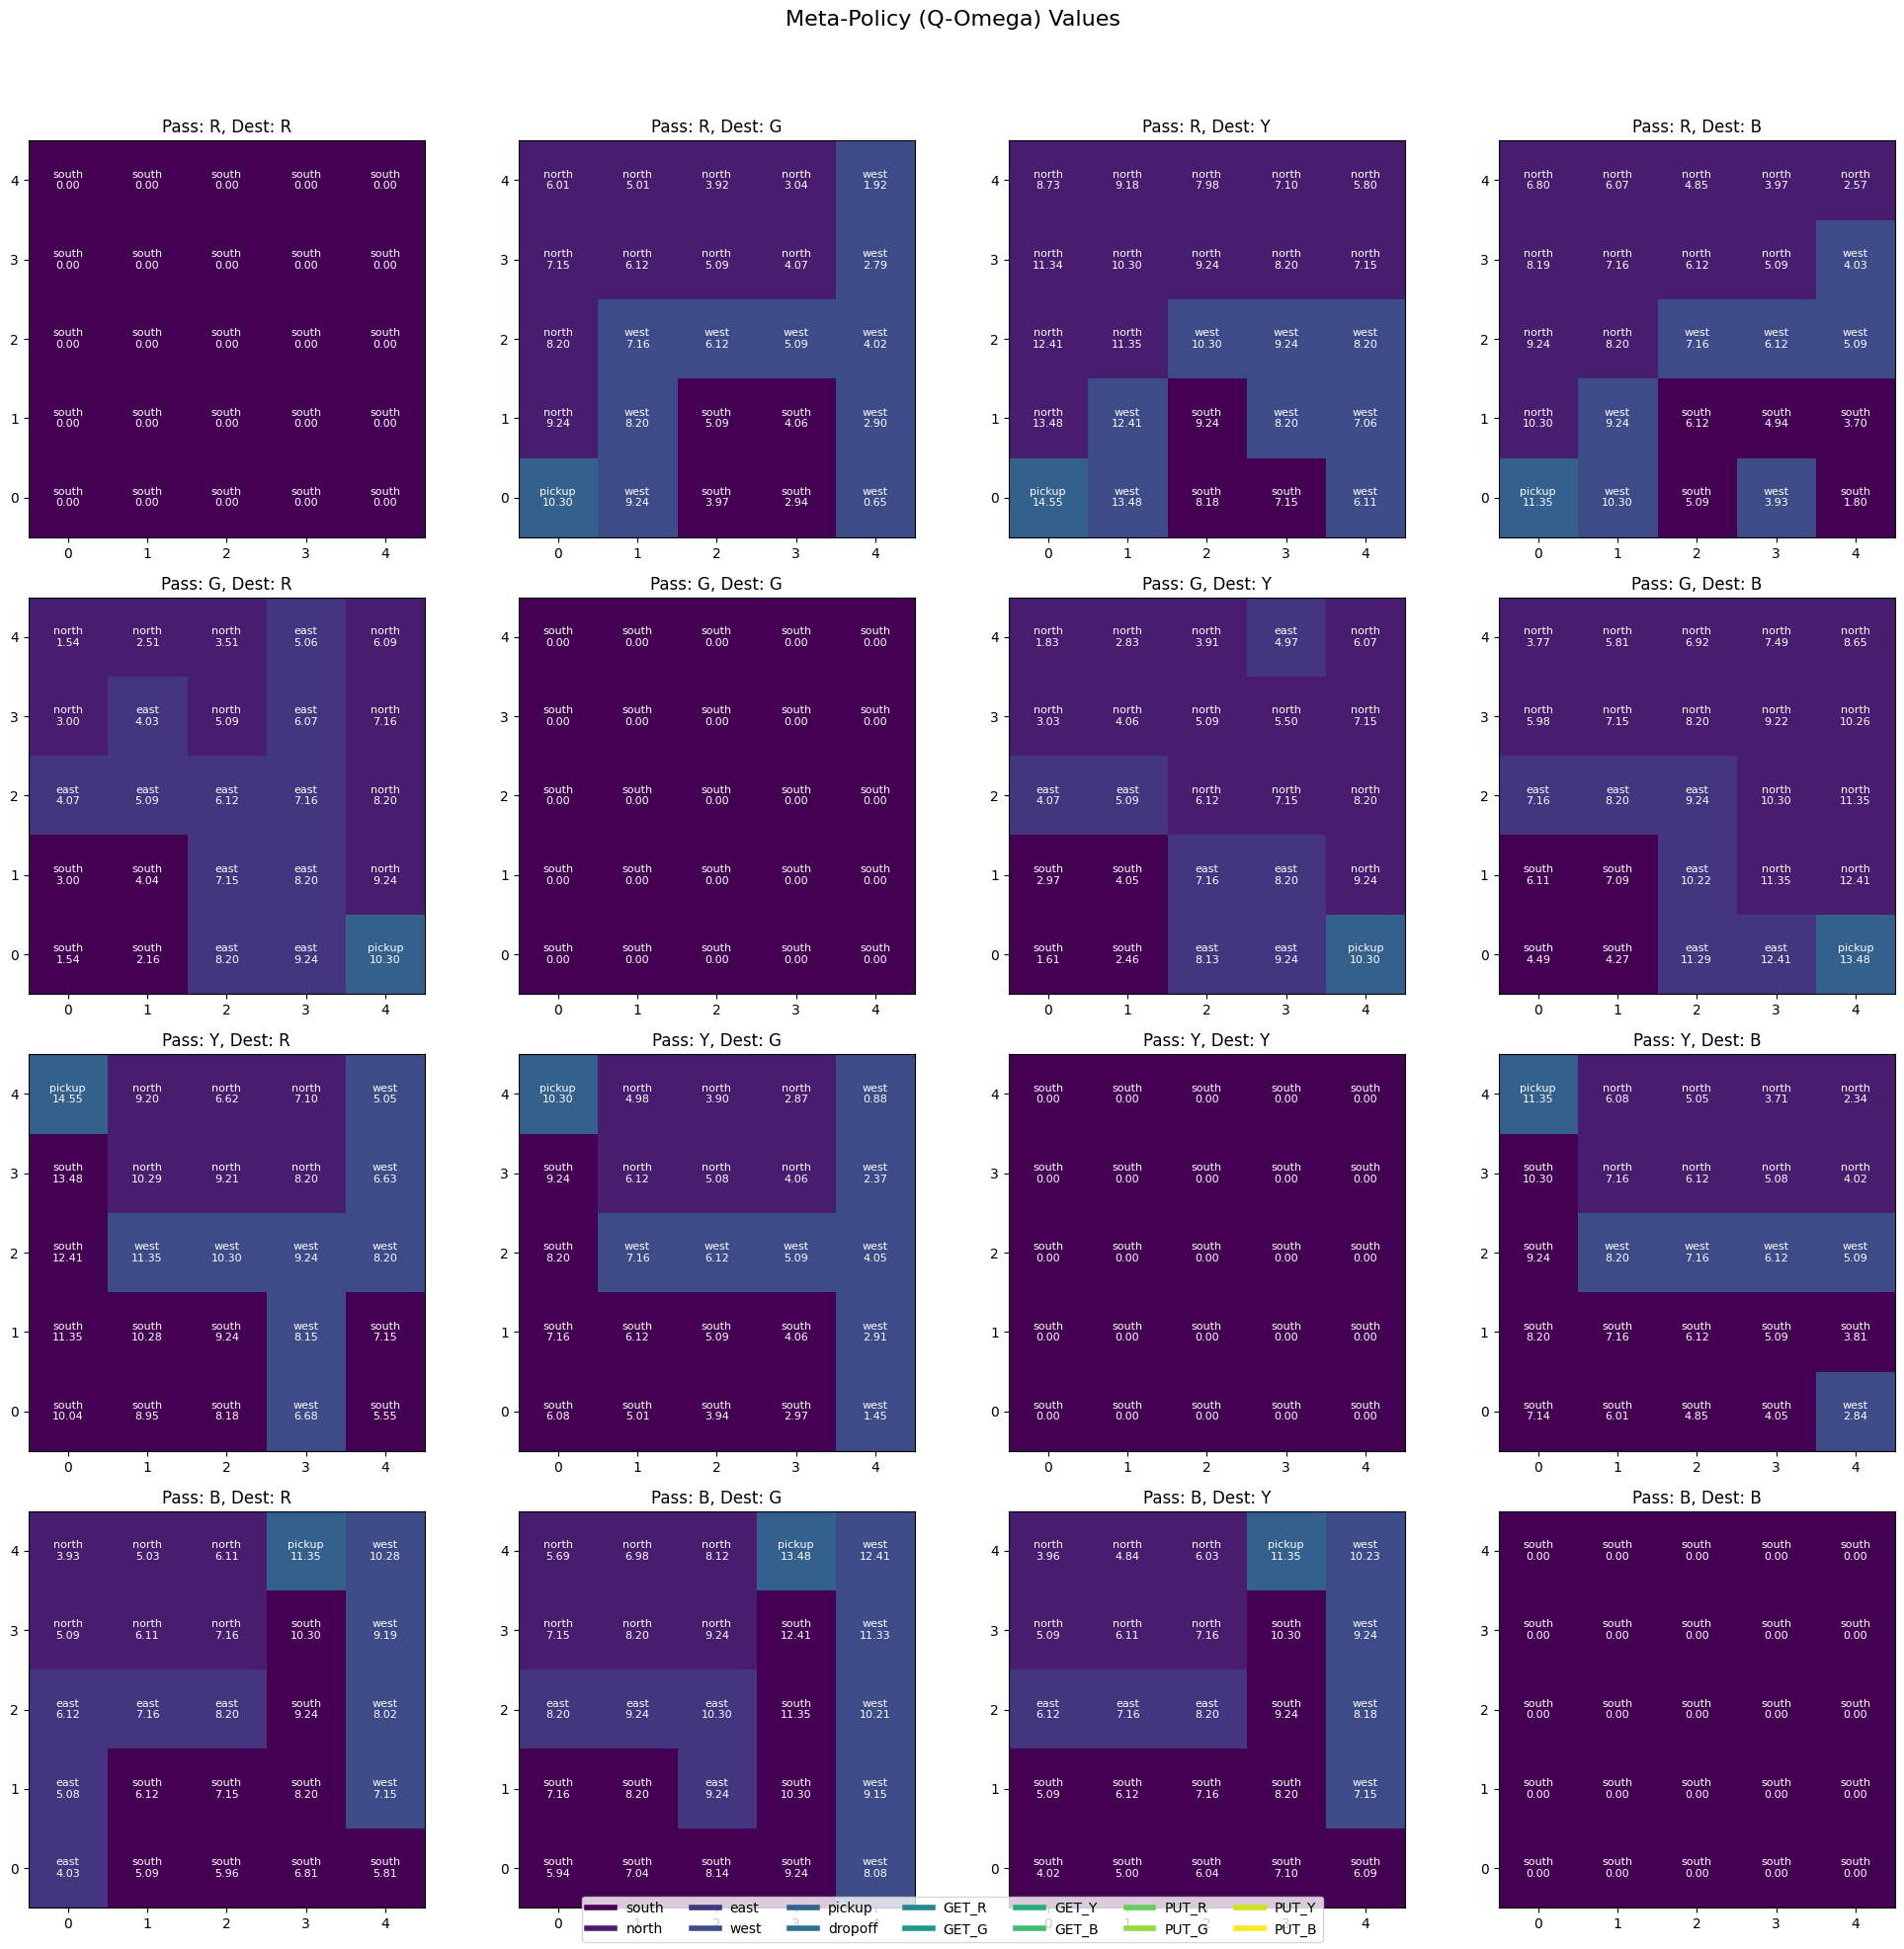

In [34]:
plot_q_omega_dashboard(intra_agent, env, options)
